In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sde_routines_scalar_reg import * 
from utils import bimodal

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# core experiment params
n1    = int(1e6)
nt    = 10000
sigma = 5
beta  = 1.3

# potentials
potential_names = ['x', 'x2', 'x3', 'x4']
DENOM = torch.tensor([1., 2., 3., 4.], device=device)

t = torch.linspace(0, 1, nt + 1, device=device)

target_theta = torch.tensor([beta/2, 5*beta, 0., -beta])

In [4]:
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

x1 = torch.from_numpy(bimodal(n1, beta)).to(device)
print(x1.shape) 

Constante de normalisation Z ≈ 5316.4306
torch.Size([1000000])


In [5]:
# regularization
lam = 1e-5
n_subsample = 10

x0, xt, barphi_e, barphi_p, eta_t, theta_t, dH, theta_reg = solve_sde(
    x1,
    n1,
    t,
    [sigma]*(nt+1),
    potential_names=potential_names,
    lam=lam,
    n_subsample=n_subsample,
    device=device,
    std_init=1,
)

# MGD (local theta)
theta_mgd = theta_t.detach().cpu() / DENOM.detach().cpu()

# Regularised (global theta)
theta_reg = theta_reg.detach().cpu() / DENOM.detach().cpu()


Step 0/10000


/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/bimodal_experiment/sde_routines_scalar_reg.py:55: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  noise_scale = torch.sqrt(torch.tensor(2 * h * sigma))


Step 200/10000
Step 400/10000
Step 600/10000
Step 800/10000
Step 1000/10000
Step 1200/10000
Step 1400/10000
Step 1600/10000
Step 1800/10000
Step 2000/10000
Step 2200/10000
Step 2400/10000
Step 2600/10000
Step 2800/10000
Step 3000/10000
Step 3200/10000
Step 3400/10000
Step 3600/10000
Step 3800/10000
Step 4000/10000
Step 4200/10000
Step 4400/10000
Step 4600/10000
Step 4800/10000
Step 5000/10000
Step 5200/10000
Step 5400/10000
Step 5600/10000
Step 5800/10000
Step 6000/10000
Step 6200/10000
Step 6400/10000
Step 6600/10000
Step 6800/10000
Step 7000/10000
Step 7200/10000
Step 7400/10000
Step 7600/10000
Step 7800/10000
Step 8000/10000
Step 8200/10000
Step 8400/10000
Step 8600/10000
Step 8800/10000
Step 9000/10000
Step 9200/10000
Step 9400/10000
Step 9600/10000
Step 9800/10000


In [6]:
t_mgd = np.linspace(0, 1, theta_mgd.shape[0])
t_reg = np.linspace(0, 1, theta_reg.shape[0])

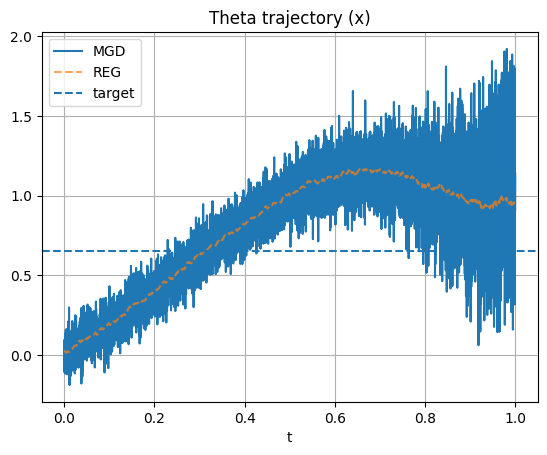

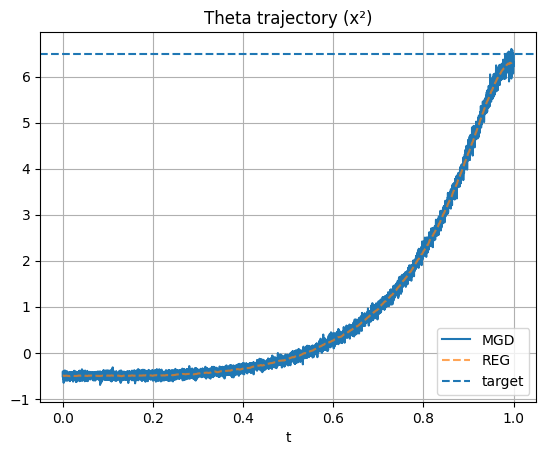

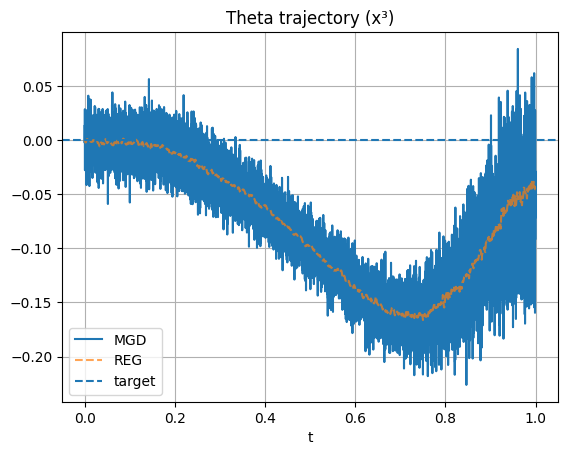

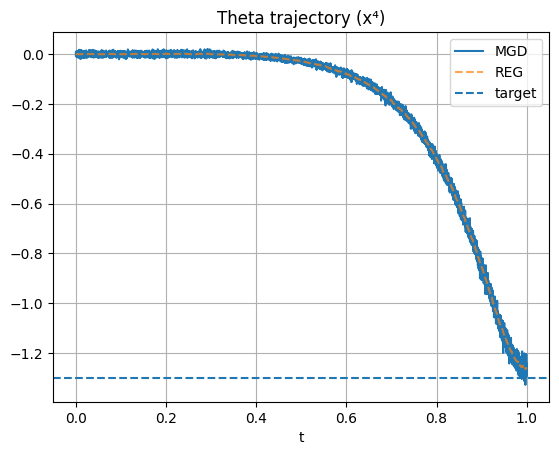

In [7]:
labels = ['x', 'x²', 'x³', 'x⁴']

for i in range(4):
    plt.figure()
    
    plt.plot(t_mgd, theta_mgd[:, i], label='MGD')
    plt.plot(t_reg, theta_reg[:, i], "--", label='REG', alpha = 0.7)
    #plt.plot(t_reg, theta_reg_thomas[:, i], "--", label='Thomas', alpha = 0.7) 
    plt.axhline(target_theta[i], linestyle='--', label='target',)
    
    plt.title(f"Theta trajectory ({labels[i]})")
    plt.xlabel("t")
    plt.legend()
    plt.grid()
    plt.show()